In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True #False if your computer sucks (mine does)

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np

m1 = 1e6
m2 = 10
a = 0.93 # 0.95
e0 = 0.58 # 0.6 just spin first
xI0 = 1.0
dist = 0.4
qS = xp.pi/4
phiS = 1.0
qK = 1 
phiK = xp.pi/3
Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 0.5

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.0

print(use_gpu)

True


In [4]:
SK_traj = EMRIInspiral(func=SuperKludgeFlux,use_gpu=use_gpu)
add_args= [chi2, evolve_1PA, evolve_primary, evolve_2PA,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p0_ = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1, m2, a, e0, xI0, *add_args])
print(p0_)

5.784879218069141


In [5]:
filename= "rishav_CVBias"

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

# with longer signals we care less about this
t0 = 10000.0  # throw away on both ends when our orbital information is weird

In [6]:
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

print(use_gpu)
der_order = 8
Ndelta=8
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = True,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=True
                       )
                   

der_order = 12
Ndelta = 8
stability_plot = True

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
emri_kwargs = {"T":T, "dt":dt}
# sef.waveform_generator.backend.uses_cupy

True


In [7]:

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.93, 7.0, 0.58, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  77.57657463779778


In [8]:
# got from Shubham's code
def cutlervallis(waveform_truth, waveform_approx, Fisher_truth, partial_approx, params_truth, PSD_func, dt, use_gpu=False):
    """
    Calculate best-fit param points using the Cutler-Vallisneri linear-bias approximation.
    params:
        waveform_truth (ndarray) : the time-series waveform from the true template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        waveform_approx (ndarray) : the time-series waveform from the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        partial_approx (ndarray) : the time-series partial derivative of the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        Fisher_truth (ndarray) : the Fisher matrix (log-mass units) at params_truth. ndarray of shape 'd x d'
        params_truth (ndarray) : the array of true params. ndarray of shape 'd'
        PSD_func (ndarray) : the frequency-domain LISA noise sensitivity curve. ndarray of shape 'N x L' where L is the length of the frequency series. 

    returns:
        CV_bias (ndarray): params_truth + np.linalg.inv(Fisher_truth) @ inner_product(partial_approx, waveform_truth - waveform_approx)
    """

#Equation 29 of cutler-vallisneri paper
    if use_gpu:
        xp = cp
    else:
        xp = np
        
    #waveform_truth = padding(waveform_truth, waveform_approx, use_gpu = use_gpu) #make waveform_truth the same length as waveform_approx
    delta_wave = waveform_truth - waveform_approx
    #truth contains 1 order PN and approx contains 0 order PN with deviations

    # calculate all the column-wise inner products
    inn_prods = []
    
    for j in range(len(Fisher_truth)):
        
        print("delta_wave.shape, partial_approx.shape: ", delta_wave.shape, partial_approx[j].shape)
                      
        inn_prod_j = inner_product(partial_approx[j], delta_wave, PSD=PSD_func, dt=dt, use_gpu = use_gpu) #should be a scalar
        if not use_gpu:
            inn_prod_j = xp.asarray(inn_prod_j)
        else:
            inn_prod_j = xp.asnumpy(inn_prod_j)
            
        print(f'inner_prod at j = {j}: ', inn_prod_j)
        inn_prods.append(inn_prod_j)
        
    inn_prods = np.array(inn_prods)
    # calculate all the param shifts
    delta_param_all = []
    
    for i in range(len(Fisher_truth)):
            
        delta_param_i = np.linalg.inv(Fisher_truth)[i,:]@inn_prods  #should be a scalars
        print(f"{param_names[i]} have delta {delta_param_i}")
        delta_param_all.append(delta_param_i)
        
    print('delta_param_all: ', delta_param_all)
    return params_truth + np.array(delta_param_all)


Body is not plunging, Fisher should be stable.
waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.93, 7.0, 0.58, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 77.57657463779778
calculating stable deltas...
Gamma_ii for m1: 985.638715443512
Gamma_ii for m1: 985.6387154453128
Gamma_ii for m1: 985.6387154339233
Gamma_ii for m1: 985.6387154731534
Gamma_ii for m1: 985.638715322238
Gamma_ii for m1: 985.6387153590052
Gamma_ii for m1: 985.6387143673282
Gamma_ii for m1: 985.6387141894883
Gamma_ii for m1: 985.6387074648563
Gamma_ii for m1: 985.638735626342
Gamma_ii for m1: 985.6387582975086
Gamma_ii for m1: 985.6388732711614
[np.float64(1.8270381238999875e-12), np.float64(1.1555439417221436e-11), np.float64(3.980174870407881e-11), np.float64(1.5311433020731484e-10), np.float64(3.7302951112751736e-11), np.float64(1.0061262505523546e-09), np.floa

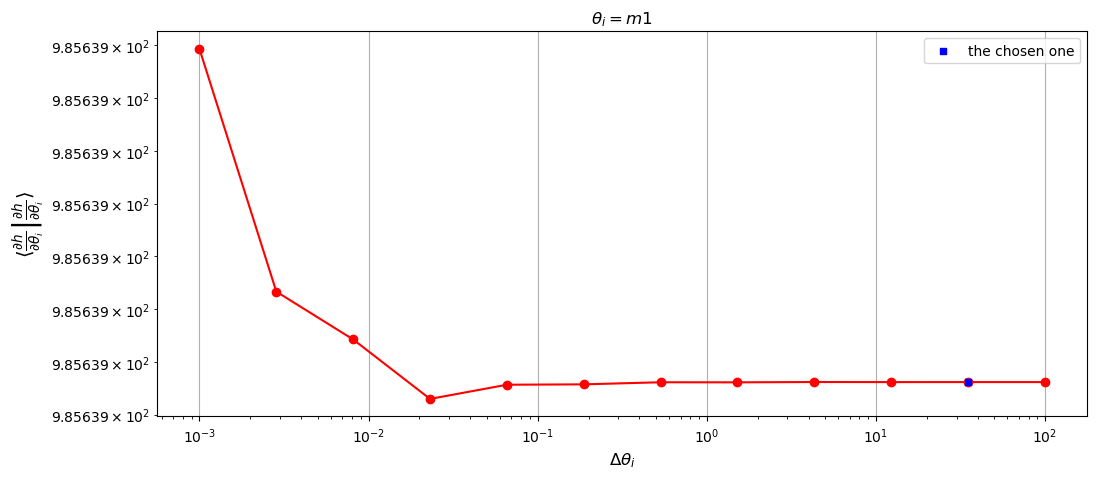

Gamma_ii for m2: 160295414750.1542
Gamma_ii for m2: 160295414746.45853
Gamma_ii for m2: 160295414790.77606
Gamma_ii for m2: 160295414768.5566
Gamma_ii for m2: 160295415007.02045
Gamma_ii for m2: 160295415178.78024
Gamma_ii for m2: 160295414817.4649
Gamma_ii for m2: 160295409405.1431
Gamma_ii for m2: 160295416100.61893
Gamma_ii for m2: 160295398576.87628
Gamma_ii for m2: 160295350011.05533
Gamma_ii for m2: 160295586948.78644
[np.float64(2.3055423742363474e-11), np.float64(2.764741303313986e-10), np.float64(1.3861564247722587e-10), np.float64(1.487652261666236e-09), np.float64(1.0715203298298424e-09), np.float64(2.2540590979861185e-09), np.float64(3.376467129000435e-08), np.float64(4.176960260594921e-08), np.float64(1.0932155757957978e-07), np.float64(3.0297710413945027e-07), np.float64(1.4781300946564389e-06)]
0


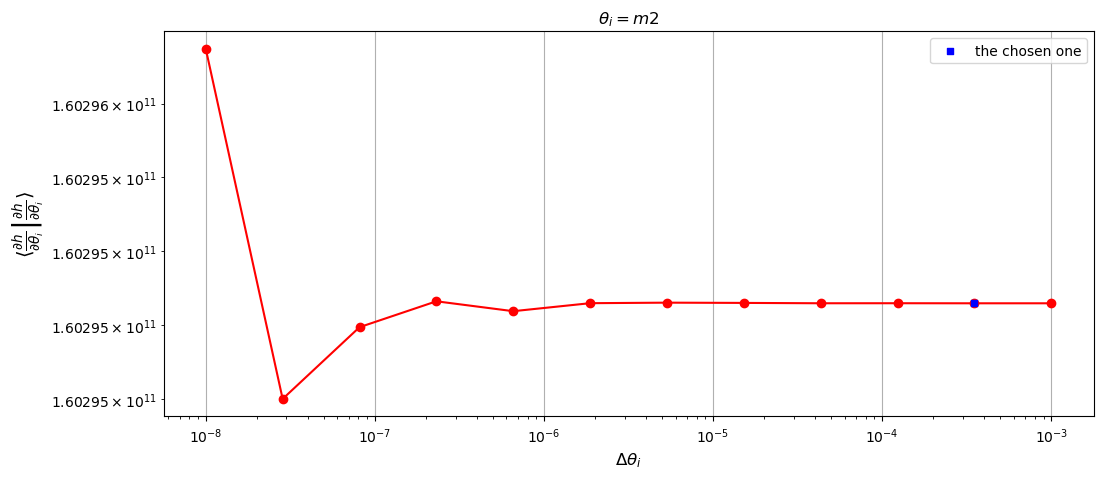

Gamma_ii for a: 9747511178275.873
Gamma_ii for a: 9747512544300.516
Gamma_ii for a: 9747516065104.568
Gamma_ii for a: 9747537819541.818
Gamma_ii for a: 9747553778925.467
Gamma_ii for a: 9747545222219.959
Gamma_ii for a: 9748130273593.85
Gamma_ii for a: 9747771275465.057
Gamma_ii for a: 9755064461141.566
Gamma_ii for a: 9752639595687.07
Gamma_ii for a: 9718415684604.473
Gamma_ii for a: 9662990895471.1
[np.float64(1.4014084479192136e-07), np.float64(3.6120012823970706e-07), np.float64(2.231787929705367e-06), np.float64(1.6372706435272216e-06), np.float64(8.778318348610594e-07), np.float64(6.001677834316977e-05), np.float64(3.682873947776758e-05), np.float64(0.0007476307005003938), np.float64(0.0002486368362846554), np.float64(0.003521552503337948), np.float64(0.005735779918756813)]
0


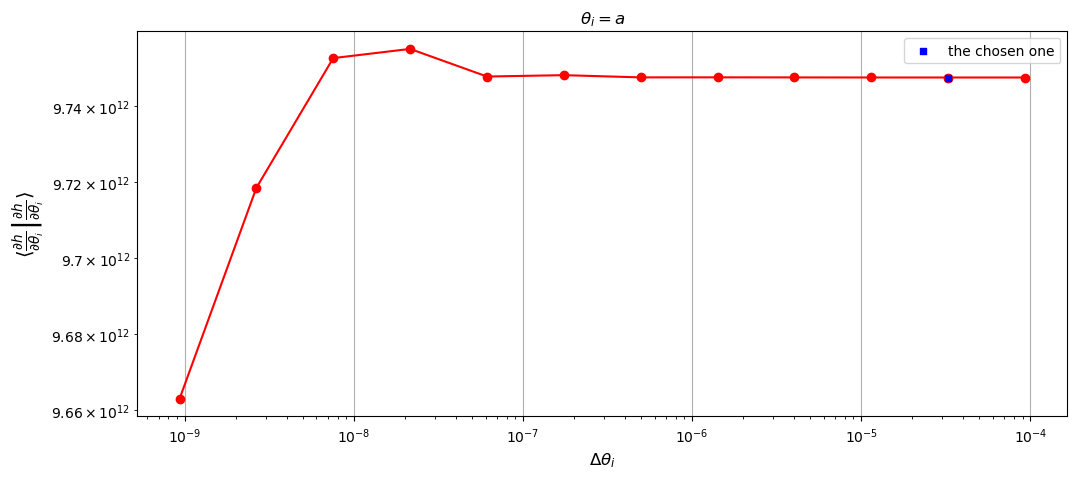

Gamma_ii for p0: 45258004029659.1
Gamma_ii for p0: 45258004976862.12
Gamma_ii for p0: 45257997827293.15
Gamma_ii for p0: 45258008121496.06
Gamma_ii for p0: 45258017530833.555
Gamma_ii for p0: 45257985286845.82
Gamma_ii for p0: 45258126197513.32
Gamma_ii for p0: 45258470074057.84
Gamma_ii for p0: 45257981445015.125
Gamma_ii for p0: 45260128932359.77
Gamma_ii for p0: 45251442300238.195
Gamma_ii for p0: 45226517603621.06
[np.float64(2.0928960879058895e-08), np.float64(1.5797360272173602e-07), np.float64(2.2745594296654635e-07), np.float64(2.0790432293630782e-07), np.float64(7.124485884648223e-07), np.float64(3.1134887663056243e-06), np.float64(7.598059412099914e-06), np.float64(1.0796527532108247e-05), np.float64(4.74476629940186e-05), np.float64(0.00019196365198579317), np.float64(0.0005511080210857804)]
0


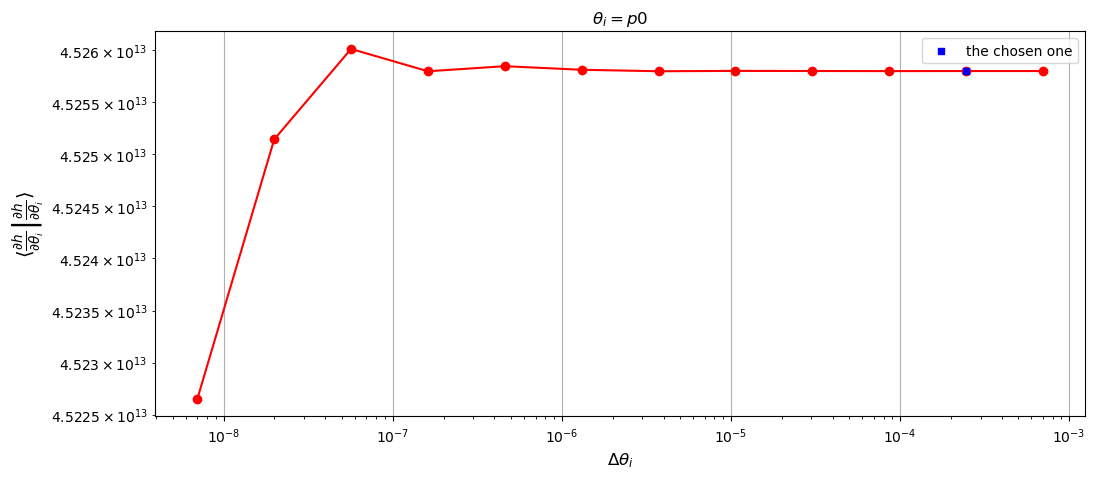

Gamma_ii for e0: 2038489051826211.8
Gamma_ii for e0: 2038489105215202.8
Gamma_ii for e0: 2038489264824783.2
Gamma_ii for e0: 2038488219570693.8
Gamma_ii for e0: 2038486907736414.0
Gamma_ii for e0: 2038488934523117.0
Gamma_ii for e0: 2038489569351930.2
Gamma_ii for e0: 2038521611964543.2
Gamma_ii for e0: 2038451543085501.5
Gamma_ii for e0: 2038728194594506.0
Gamma_ii for e0: 2039438649720203.0
Gamma_ii for e0: 2038728015320481.5
[np.float64(2.6190471591636856e-08), np.float64(7.829797451188398e-08), np.float64(5.127594456837876e-07), np.float64(6.435333358145984e-07), np.float64(9.94259359800815e-07), np.float64(3.1142117320316857e-07), np.float64(1.571855428214971e-05), np.float64(3.437358090724603e-05), np.float64(0.00013569808360820986), np.float64(0.000348358174831329), np.float64(0.00034856753543448536)]
0


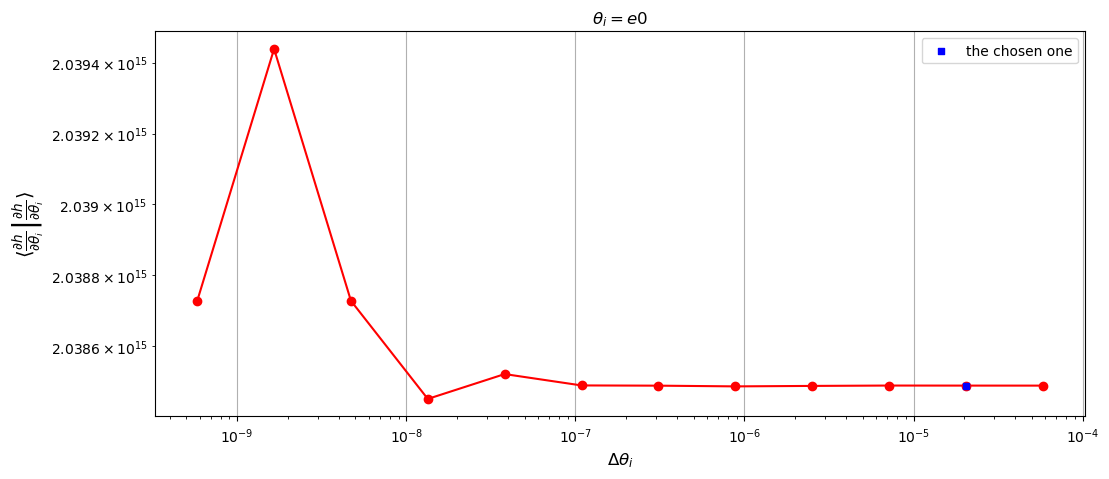

Gamma_ii for qS: 18457.017793491847
Gamma_ii for qS: 18457.01782173045
Gamma_ii for qS: 18457.0178217373
Gamma_ii for qS: 18457.017821737227
Gamma_ii for qS: 18457.01782173662
Gamma_ii for qS: 18457.01782174091
Gamma_ii for qS: 18457.017821737136
Gamma_ii for qS: 18457.017821767542
Gamma_ii for qS: 18457.017821723704
Gamma_ii for qS: 18457.01782203654
Gamma_ii for qS: 18457.017821738158
Gamma_ii for qS: 18457.01782240325
[np.float64(1.529965618163874e-09), np.float64(3.711495627254532e-13), np.float64(3.942109003987835e-15), np.float64(3.2916610183299504e-14), np.float64(2.323873257850365e-13), np.float64(2.0439835185677026e-13), np.float64(1.6474073527638104e-12), np.float64(2.3751206749044106e-12), np.float64(1.6949491873271227e-11), np.float64(1.6166391919903095e-11), np.float64(3.603462129870229e-11)]
2


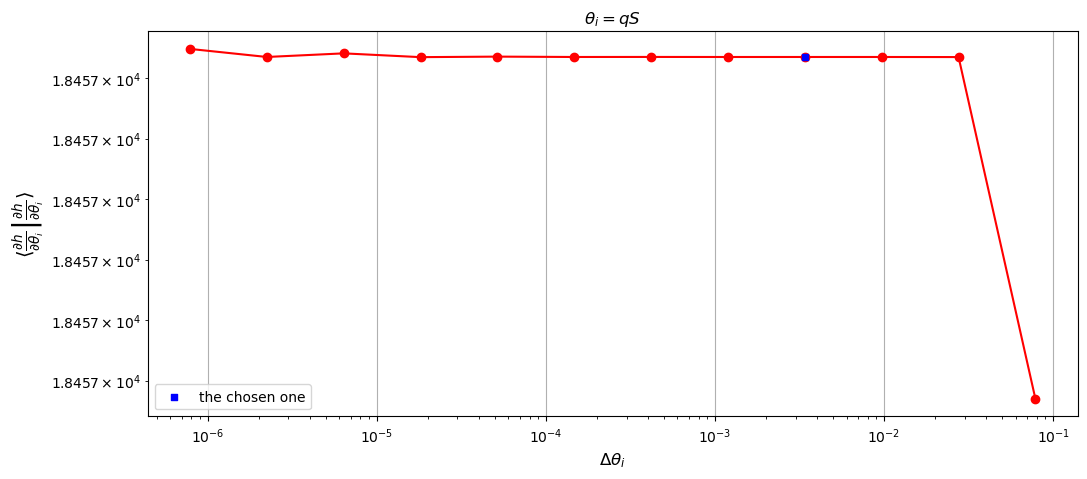

Gamma_ii for phiS: 356641.84525141877
Gamma_ii for phiS: 356641.8452471389
Gamma_ii for phiS: 356641.84524713777
Gamma_ii for phiS: 356641.84524713777
Gamma_ii for phiS: 356641.84524713777
Gamma_ii for phiS: 356641.84524713777
Gamma_ii for phiS: 356641.84524713765
Gamma_ii for phiS: 356641.84524713823
Gamma_ii for phiS: 356641.8452471385
Gamma_ii for phiS: 356641.8452471374
Gamma_ii for phiS: 356641.84524713724
Gamma_ii for phiS: 356641.8452471484
[np.float64(1.2000534846603974e-11), np.float64(3.1009977435191516e-15), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(3.2642081510727925e-16), np.float64(1.6321040755363936e-15), np.float64(8.160520377681961e-16), np.float64(3.1009977435191548e-15), np.float64(4.896312226609194e-16), np.float64(3.133639825029786e-14)]
2


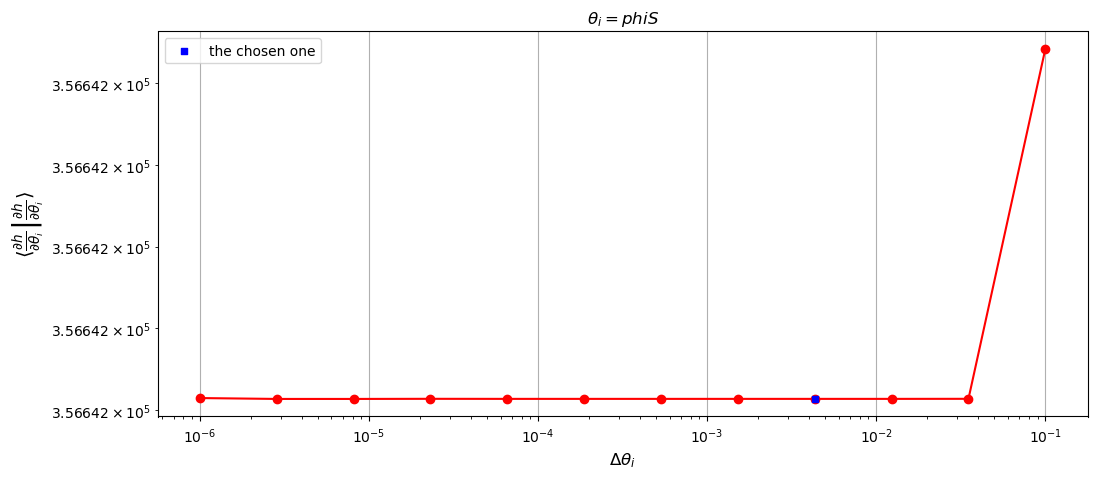

Gamma_ii for dev0p: 5147322395882.008
Gamma_ii for dev0p: 5147319740115.653
Gamma_ii for dev0p: 5147320170272.453
Gamma_ii for dev0p: 5147323846761.331
Gamma_ii for dev0p: 5147289163388.634
Gamma_ii for dev0p: 5147375654695.787
Gamma_ii for dev0p: 5147325879046.933
Gamma_ii for dev0p: 5147921990058.585
Gamma_ii for dev0p: 5146922933889.151
Gamma_ii for dev0p: 5131493357142.893
Gamma_ii for dev0p: 5138382120873.141
Gamma_ii for dev0p: 5148761553940.458
[np.float64(5.159513083662675e-07), np.float64(8.356907780654313e-08), np.float64(7.142524906885186e-07), np.float64(6.7381822929163735e-06), np.float64(1.6802991068743358e-05), np.float64(9.670195752927254e-06), np.float64(0.00011579643452319678), np.float64(0.00019410746620188472), np.float64(0.003006839466094457), np.float64(0.0013406483924705609), np.float64(0.00201590867212986)]
1


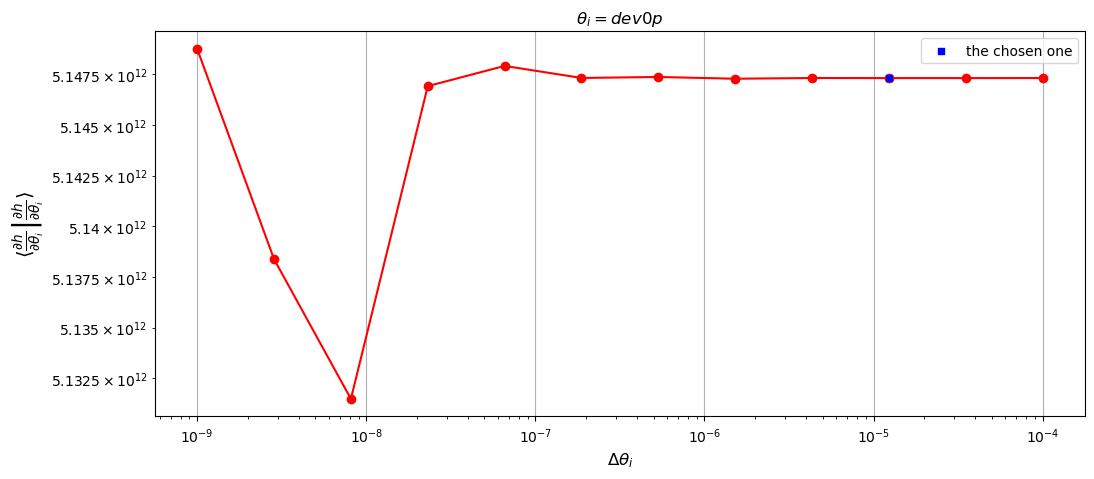

Gamma_ii for dev0e: 3028957937336.43
Gamma_ii for dev0e: 3028958407490.677
Gamma_ii for dev0e: 3028957720868.39
Gamma_ii for dev0e: 3028979083127.6445
Gamma_ii for dev0e: 3028958455675.0537
Gamma_ii for dev0e: 3029092482364.1426
Gamma_ii for dev0e: 3029036103159.71
Gamma_ii for dev0e: 3028011962726.61
Gamma_ii for dev0e: 3027944789540.304
Gamma_ii for dev0e: 3033464405495.686
Gamma_ii for dev0e: 3037366495162.3555
Gamma_ii for dev0e: 3035035056185.5083
[np.float64(1.5521977634929886e-07), np.float64(2.2668599231033238e-07), np.float64(7.052626864737679e-06), np.float64(6.8100810534963715e-06), np.float64(4.424648302063798e-05), np.float64(1.861291926293178e-05), np.float64(0.0003382220564868238), np.float64(2.2184415824788583e-05), np.float64(0.0018195749867320095), np.float64(0.0012846950385751379), np.float64(0.0007681753039707444)]
0


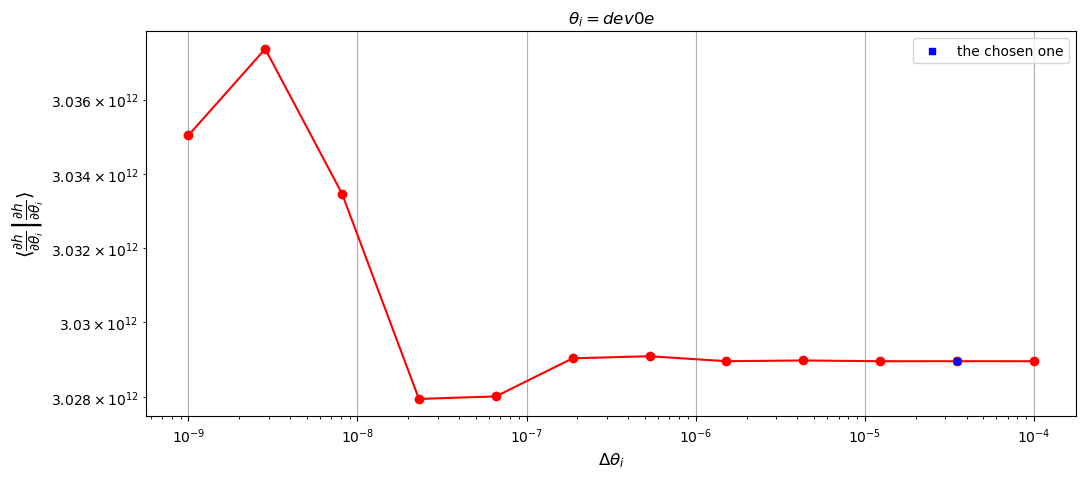

stable deltas: {'m1': 35.11191734215131, 'm2': 0.0003511191734215131, 'a': 3.265408312820073e-05, 'p0': 0.0002457834213950592, 'e0': 2.0364912058447762e-05, 'qS': 0.00339980115994862, 'phiS': 0.004328761281083062, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': 1.2328467394420658e-05, 'dev0e': 3.511191734215135e-05}
Time taken to compute stable deltas is 133.43246865272522 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 11.769349336624146 seconds


In [9]:
#initialize the 0PA (approximate) model
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}


param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}
der_order = 8
Ndelta = 12

Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,
            )


In [23]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J

In [24]:
Fisher[-1].shape

(11, 11)

In [25]:
fisher_=Fisher[-1].copy()
fisher_
# sef.deltas["Phi_phi0"] = 1e-5
# sef.deltas["Phi_r0"] = 1e-5
sef.deltas

{'m1': 35.11191734215131,
 'm2': 0.0003511191734215131,
 'a': 3.265408312820073e-05,
 'p0': 0.0002457834213950592,
 'e0': 2.0364912058447762e-05,
 'qS': 0.00339980115994862,
 'phiS': 0.004328761281083062,
 'Phi_phi0': 0.0,
 'Phi_r0': 0.0,
 'dev0p': 1.2328467394420658e-05,
 'dev0e': 3.511191734215135e-05}

In [26]:
#in this code cell, we are transfroming fisher for numerical stability and will remove parameters that are causing problem

print("Transforming to log-mass")
Fisher_transform = logmasstransform(fisher_, m1)
print("Checking log-mass Fisher positive-definiteness...")
check_flag = True
rows_to_remove = []
for j in range(len(param_names)):
    if param_names[j] in []:#'dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']:
            rows_to_remove.append(j)

rows_to_remove = np.array(rows_to_remove)
    
if len(rows_to_remove) > 0:
    Fisher_transformed = np.delete(np.delete(Fisher_transform,rows_to_remove,axis=0),rows_to_remove,axis=1)
    #Fisher = np.delete(np.delete(Fisher,rows_to_remove,axis=0),rows_to_remove,axis=1)

if (np.linalg.eigvals(Fisher_transform) < 0.0).any():
    check_flag = False
    print('positive definiteness failed for: ', i)
        
if check_flag:
    print("positive-definiteness check passed!")
pd.DataFrame(Fisher_transform)

Transforming to log-mass
Checking log-mass Fisher positive-definiteness...
positive-definiteness check passed!


,0,1,2,3,4,5,6,7,8,9,10
0,9.856387e+14,-1.228519e+13,8.531601e+13,2.110797e+14,1.410001e+15,-3.428151e+09,1.580624e+10,-4.143686e+09,-6.968359e+09,-6.895867e+13,-5.390431e+13
1,-1.228519e+13,1.602954e+11,-1.158812e+12,-2.645119e+12,-1.718280e+13,3.878021e+07,-1.787958e+08,4.687116e+07,7.497862e+07,9.074559e+11,6.956369e+11
2,8.531601e+13,-1.158812e+12,9.747513e+12,1.862848e+13,1.169208e+14,-2.751851e+08,1.269102e+09,-3.326480e+08,-4.058641e+08,-6.636083e+12,-4.953000e+12
3,2.110797e+14,-2.645119e+12,1.862848e+13,4.525800e+13,3.011971e+14,-7.310672e+08,3.370793e+09,-8.836620e+08,-1.462421e+09,-1.486702e+13,-1.158654e+13
4,1.410001e+15,-1.718280e+13,1.169208e+14,3.011971e+14,2.038489e+15,-5.124255e+09,2.362695e+10,-6.193981e+09,-1.062312e+10,-9.603575e+13,-7.580801e+13
5,-3.428151e+09,3.878021e+07,-2.751851e+08,-7.310672e+08,-5.124255e+09,1.845702e+04,-7.709594e+04,2.020869e+04,3.375250e+04,2.151255e+08,1.727123e+08
6,1.580624e+10,-1.787958e+08,1.269102e+09,3.370793e+09,2.362695e+10,-7.709594e+04,3.566418e+05,-9.320600e+04,-1.556189e+05,-9.918415e+08,-7.962923e+08
7,-4.143686e+09,4.687116e+07,-3.326480e+08,-8.836620e+08,-6.193981e+09,2.020869e+04,-9.320600e+04,2.443358e+04,4.080230e+04,2.600089e+08,2.087489e+08
8,-6.968359e+09,7.497862e+07,-4.058641e+08,-1.462421e+09,-1.062312e+10,3.375250e+04,-1.556189e+05,4.080230e+04,8.491302e+04,4.101394e+08,3.397240e+08
9,-6.895867e+13,9.074559e+11,-6.636083e+12,-1.486702e+13,-9.603575e+13,2.151255e+08,-9.918415e+08,2.600089e+08,4.101394e+08,5.147320e+12,3.928019e+12


In [27]:
delats=sef.deltas
param_name = sef.param_names

In [28]:
parameters = {}
for i in range(len(param_names_com)):
    parameters[param_names_com[i]] = pars_list_com[i]


order = 8 #order of finite-difference derivative
kind = "central" #kind of finite-difference derivative
parameters

{'m1': 1000000.0,
 'm2': 10,
 'a': 0.93,
 'p0': 7.0,
 'e0': 0.58,
 'xI0': 1.0,
 'dist': 0.4,
 'qS': 0.7853981633974483,
 'phiS': 1.0,
 'qK': 1,
 'phiK': 1.0471975511965976,
 'Phi_phi0': 0.9,
 'Phi_theta0': 0.5,
 'Phi_r0': 0.4,
 'chi2': 0.0,
 'evolve_1PA': False,
 'evolve_primary': False,
 'evolve_2PA': False,
 'deviation_included': True,
 'dev0p': 0.0,
 'dev0e': 0.0,
 'dev1p': 0.0,
 'dev1e': 0.0,
 'dev2p': 0.0,
 'dev2e': 0.0}

In [29]:
# del sef
sef.wave_params_list

[1000000.0,
 10,
 0.93,
 7.0,
 0.58,
 1.0,
 0.4,
 0.7853981633974483,
 1.0,
 1,
 1.0471975511965976,
 0.9,
 0.5,
 0.4,
 0.0,
 False,
 False,
 False,
 True,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [30]:
sef.waveform_derivative_kwargs

{'parameters': {'m1': 1000000.0,
  'm2': 10,
  'a': 0.93,
  'p0': 7.0,
  'e0': 0.58,
  'xI0': 1.0,
  'dist': 0.4,
  'qS': 0.7853981633974483,
  'phiS': 1.0,
  'qK': 1,
  'phiK': 1.0471975511965976,
  'Phi_phi0': 0.9,
  'Phi_theta0': 0.5,
  'Phi_r0': 0.4,
  'chi2': 0.0,
  'evolve_1PA': False,
  'evolve_primary': False,
  'evolve_2PA': False,
  'deviation_included': True,
  'dev0p': 0.0,
  'dev0e': 0.0,
  'dev1p': 0.0,
  'dev1e': 0.0,
  'dev2p': 0.0,
  'dev2e': 0.0},
 'order': 8,
 'dt': 10.0,
 'T': 0.5}

In [31]:
print(f"Calculating Cutler-Vallisneri Biases")
removed_params = []
print(f'calculating derivatives at {param_names}...')
#Fisher = np.zeros((sef.npar,sef.npar), dtype=np.float64)
dtv = []

for k in range(sef.npar):
        temp=sef.derivative(*sef.wave_params_list,
                             param_to_vary=sef.param_names[k],
                               delta=sef.deltas[sef.param_names[k]],
                               kind=kind, **sef.waveform_derivative_kwargs,use_gpu=use_gpu)
        print(temp)
        print("\n",temp.shape)
        print(f"calculting derivative for {sef.param_names[k]}\n")
        dtv_=np.vstack([temp.real,temp.imag])
        print(dtv_)
        dtv.append(dtv_)
        

print("Finished derivatives")
if sef.use_gpu:
        dtv = cp.asnumpy(cp.asarray(dtv)) #h5py only stores numpy
          
#Jacobian transform to log-masses
for k in range(sef.npar):
    if sef.param_names[k] == 'm1':
        dtv[k] *= m1 #to obtain \partial_{log m1}h

Calculating Cutler-Vallisneri Biases
calculating derivatives at ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0', 'dev0p', 'dev0e']...
[ 5.46525571e-33+1.63161367e-32j  2.19370956e-28+3.76387471e-29j
  3.50851832e-28+1.71012769e-28j ... -6.46796383e-22+7.54310139e-22j
 -9.21140714e-22+3.56329124e-22j -9.51458228e-22-1.12590011e-22j]

 (1577908,)
calculting derivative for m1

[[ 5.46525571e-33  2.19370956e-28  3.50851832e-28 ... -6.46796383e-22
  -9.21140714e-22 -9.51458228e-22]
 [ 1.63161367e-32  3.76387471e-29  1.71012769e-28 ...  7.54310139e-22
   3.56329124e-22 -1.12590011e-22]]
[ 5.46526117e-23+1.63161341e-22j  7.37816388e-24+1.62499975e-22j
 -3.22134429e-23+1.49787858e-22j ...  1.00726715e-17-1.17060041e-17j
  1.43189649e-17-5.52456001e-18j  1.47903556e-17+1.74983187e-18j]

 (1577908,)
calculting derivative for m2

[[ 5.46526117e-23  7.37816388e-24 -3.22134429e-23 ...  1.00726715e-17
   1.43189649e-17  1.47903556e-17]
 [ 1.63161341e-22  1.62499975e-22  1.49787858e-

In [32]:
params_truth_in = np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,dev_0_p,dev_0_e])
#params_truth_in_transformed = np.array([np.log(m1), m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,dev_0_p,dev_0_e])

# param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

params_truth_in_considered = np.array([np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0,Phi_r0,dev_0_p,dev_0_e])
#params_truth_in_considered = np.array([np.log(m1), m2, a, p0, e0, dev_0_p, dev_0_e])
print(params_truth_in_considered)
waveform_approx = sef.waveform
waveform_approx

[13.81551056 10.          0.93        7.          0.58        0.78539816
  1.          0.9         0.4         0.          0.        ]


array([[ 2.73265791e-22,  3.68899434e-23, -1.61070796e-22, ...,
        -8.55339067e-22, -4.25967314e-22,  8.65137733e-23],
       [-8.15814862e-22, -8.12507759e-22, -7.48945750e-22, ...,
         7.47219978e-22,  1.05104575e-21,  1.11607248e-21]],
      shape=(2, 1577908))

In [38]:
#initializing the 1PA (True GR model in our analysis)
evolve_1PA = True 
evolve_primary = False
evolve_2PA = False #for approximate model
dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
deviation_included=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
print(add_args)
waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
waveform_true= xp.asarray(waveform_true)

[0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


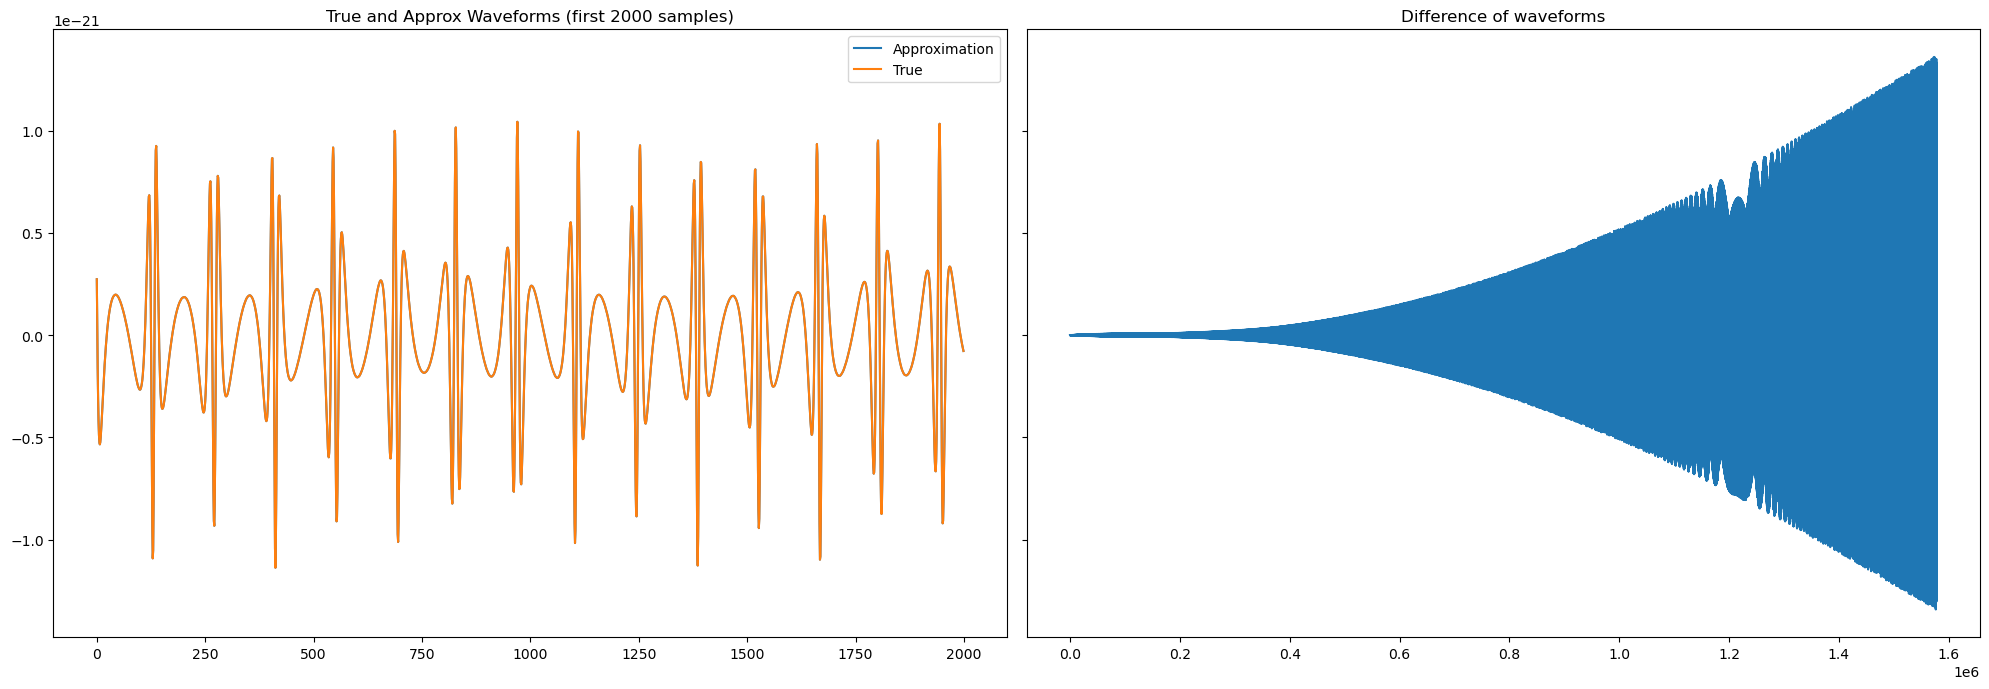

In [39]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# Plot the first 2000 samples of both waveforms
axs[0].plot(waveform_approx[0][0:2000].get(), label="Approximation")
axs[0].plot(waveform_true[0][0:2000].get(), label="True")
axs[0].set_title("True and Approx Waveforms (first 2000 samples)")
axs[0].legend()

# Plot the difference
axs[1].plot(((waveform_true[0] - waveform_approx[0])[0:]).get())
axs[1].set_title("Difference of waveforms")

plt.tight_layout()

In [40]:
biased_params = cutlervallis(waveform_truth=waveform_true, waveform_approx=waveform_approx,
                                 Fisher_truth=Fisher_transform, partial_approx=dtv,
                                 params_truth=params_truth_in_considered, PSD_func = sef.PSD_funcs, dt = dt,
                                  use_gpu=use_gpu)
print(biased_params)

if use_gpu:
        biased_params = cp.asnumpy(cp.asarray(biased_params))

#prior box on chi2
# if 'chi2' not in removed_params:
#     index_chi2 = np.where(param_names == 'chi2')
        
#     if biased_params[index_chi2] > 1.0:
#         biased_params[index_chi2] = 1.0
#     elif biased_params[index_chi2] < -1.0:
#         biased_params[index_chi2] = -1.0

#prior box on cyclic parameters (phases and such)
cyclic_priors = {'qS' : np.pi, 'phiS' : 2 * np.pi, 'qK' : np.pi, 'phiK' : 2 * np.pi, 'Phi_phi0' : 2 * np.pi, 'Phi_r0' : 2 * np.pi}
param_names_in = np.array(param_names)
for param in list(cyclic_priors.keys()):
    if param not in removed_params:
        print(f"modulo {cyclic_priors[param]} for param {param}")
            
        index = np.where(param_names_in == param) 
        biased_params[index] %= cyclic_priors[param]


print('biased params: ', biased_params)

#calculate the sigma contour as the Mahalanobis distance between the true and biased params (https://en.wikipedia.org/wiki/Mahalanobis_distance):
    
sigma_contour = np.sqrt((biased_params - params_truth_in_considered)@Fisher_transform@(biased_params - params_truth_in_considered))
sigma_contour /= np.sqrt(len(params_truth_in_considered)) #scaled Mahalonobis distance for dimensional generality
    
print('sigma contours: ', sigma_contour)

delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 0:  140799.29622113385
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 1:  -1850.0027846682049
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 2:  14733.12357537777
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 3:  30538.302707890354
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 4:  196340.8025271487
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 5:  -1.629980155746888
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 6:  -0.9981788574346117
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 7:  -0.571581975694452
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 8:  -0.8012972362465984
delta_wave.shape, partial_a

In [41]:
print(sigma_contour)

0.03074055288232399


In [42]:
biased_params

array([ 1.38155090e+01,  1.00012620e+01,  9.29999210e-01,  7.00000502e+00,
        5.80000238e-01,  7.84543151e-01,  9.97045612e-01,  8.89423634e-01,
        4.00004721e-01, -1.27513365e-04, -1.27659605e-04])

In [43]:
params_truth_in_considered

array([13.81551056, 10.        ,  0.93      ,  7.        ,  0.58      ,
        0.78539816,  1.        ,  0.9       ,  0.4       ,  0.        ,
        0.        ])

# plot ig

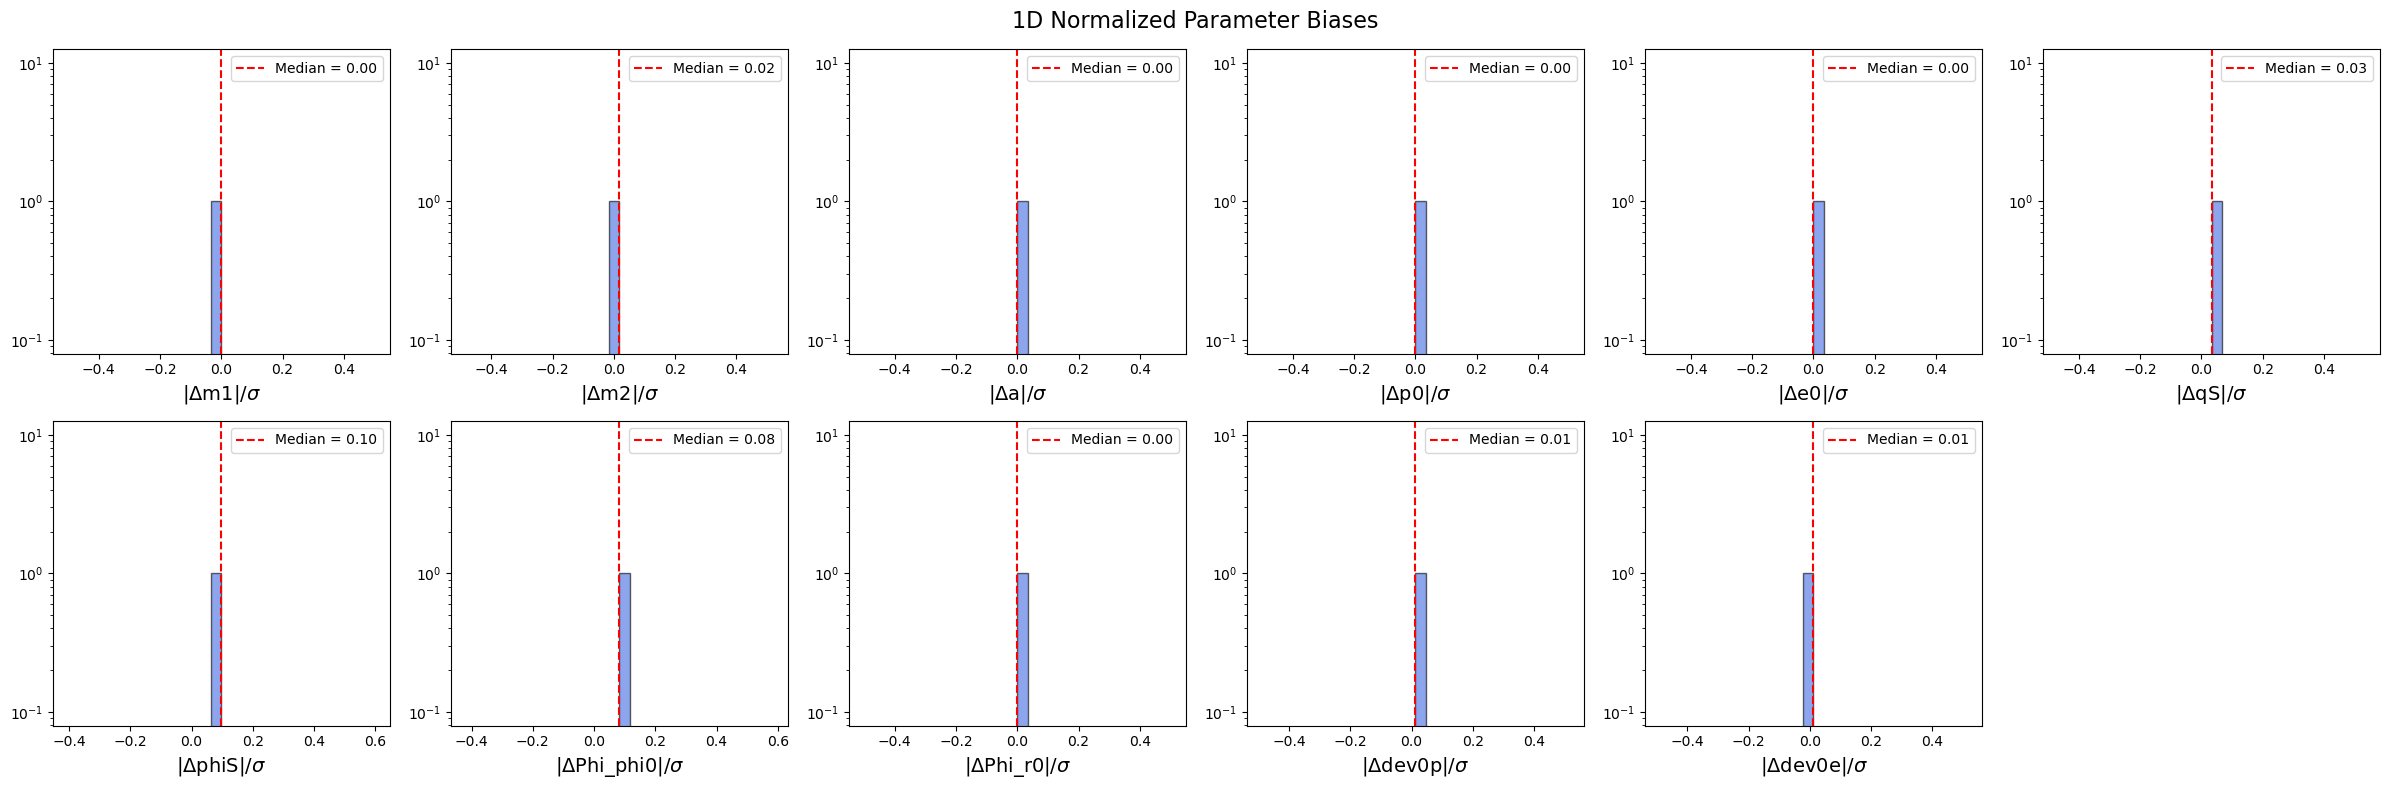

In [44]:
#used gpt (boring part)

# === PARAMETERS ===
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']


params_truth_in_considered = np.array([
    np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_0_p, dev_0_e
])
truevals_i = params_truth_in_considered

Fisher_transformed = Fisher_transform.copy()

# === REMOVE PARAMETERS IF SPECIFIED ===
rows_to_remove = [i for i, name in enumerate(param_names) if name in removed_params]
rows_to_remove = np.array(rows_to_remove)

if len(rows_to_remove) > 0:
    Fisher_transformed = np.delete(Fisher_transformed, rows_to_remove, axis=0)
    Fisher_transformed = np.delete(Fisher_transformed, rows_to_remove, axis=1)
   # param_names_plot = np.delete(param_names_plot, rows_to_remove, axis=0)
    truevals_i = np.delete(truevals_i, rows_to_remove, axis=0)

# === COMPUTE SIGMAS ===
covariance = np.linalg.inv(Fisher_transformed)
sigmas_params = np.sqrt(np.diag(covariance))

# === COMPUTE NORMALIZED BIASES ===
sigmabias_1D = np.abs(biased_params - truevals_i) / sigmas_params

# === PLOT ===
n_params = len(param_names)
ncols = int(np.ceil(n_params / 2))

fig, axs = plt.subplots(2, ncols, figsize=(4 * ncols, 8))
axs = axs.flatten()

for i, name in enumerate(param_names):
    axs[i].hist(sigmabias_1D[i], bins=30, histtype='stepfilled',
                color='royalblue', alpha=0.6, edgecolor='k')
    axs[i].set_xlabel(r"$|\Delta $" + rf"{name}" + r"$|/\sigma$", fontsize=14)
    axs[i].set_yscale('log')
    axs[i].axvline(np.median(sigmabias_1D[i]), color='r', linestyle='--',
                   label=f"Median = {np.median(sigmabias_1D[i]):.2f}")
    axs[i].legend(fontsize=10)

# Hide any unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle("1D Normalized Parameter Biases", fontsize=16)
plt.show()



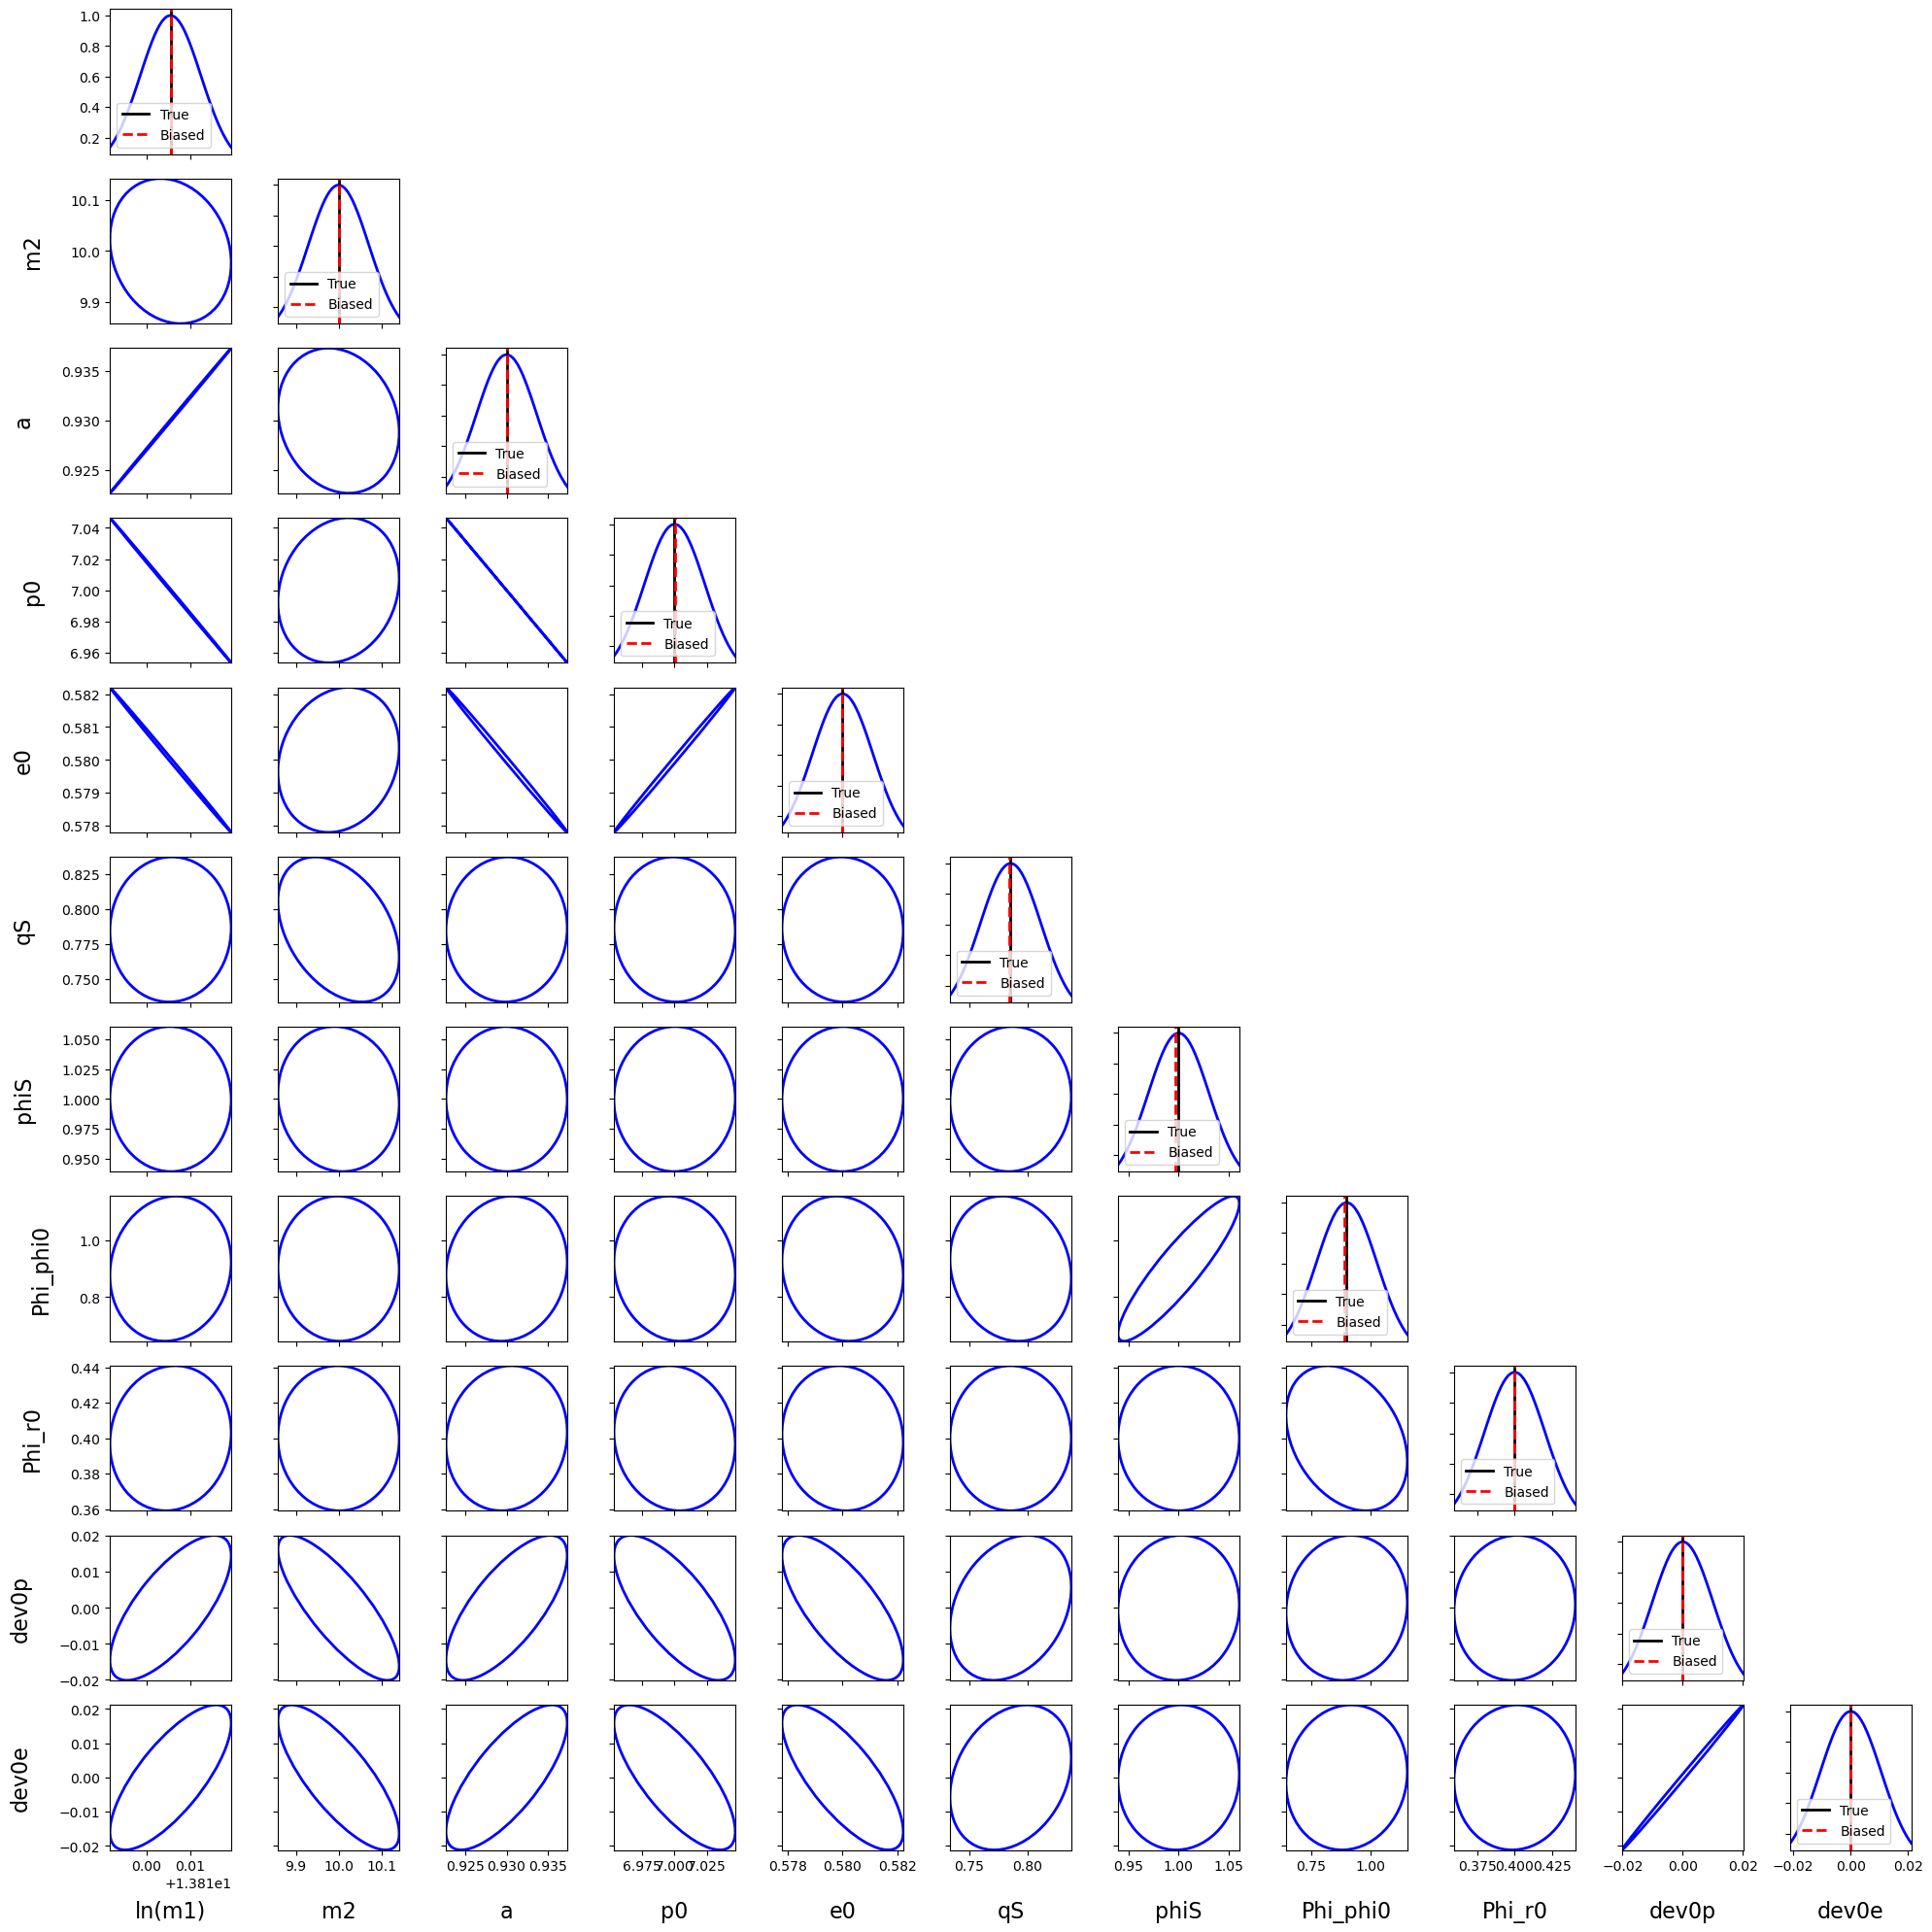

In [45]:
from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = params_truth_in_considered
# param_names_plot = [
#     r'$\log{m_1}$', r'$m_2$', r'$a$', r'$p_0$', r'$e_0$',
#     r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
#     r'dev0_p', r'dev0_e'
# ]
param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = params_truth_in_considered[i]

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)
# === ADD TRUE AND BIASED PARAMETER LINES ===
for i in range(len(param_names)):
    # Diagonal subplot (1D)
    ax = axs[i, i]
    ax.axvline(params_truth_in_considered[i], color='k', linestyle='-', lw=2, label='True')
    ax.axvline(biased_params[i], color='r', linestyle='--', lw=2, label='Biased')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


In [46]:
biased_params

array([ 1.38155090e+01,  1.00012620e+01,  9.29999210e-01,  7.00000502e+00,
        5.80000238e-01,  7.84543151e-01,  9.97045612e-01,  8.89423634e-01,
        4.00004721e-01, -1.27513365e-04, -1.27659605e-04])

In [47]:
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
dev_0_p=biased_params[9]
dev_0_e=biased_params[10]
# param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
deviation_included=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

pars_list = [np.exp(biased_params[0]), biased_params[1], biased_params[2], biased_params[3], \
             biased_params[4], xI0, dist, biased_params[5], biased_params[6], qK, phiK, biased_params[7], Phi_theta0,\
               biased_params[8]]

# superkludge_wave_biased = GenerateEMRIWaveform(SuperKludgeWaveform,\
#                                     sum_kwargs=sum_kwargs,\
#                                     return_list=True,
#                                     mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
#                                     inspiral_kwargs=inspiral_kwargs,
#                                     use_gpu=use_gpu)

waveform_biased = superkludge_wave(*pars_list, *add_args, dt=dt, T=T)


In [48]:
deviation=params_truth_in_considered-biased_params
print("Higher",biased_params)
print("\nTrue",params_truth_in_considered)
print("\nlower",params_truth_in_considered+deviation)

Higher [ 1.38155090e+01  1.00012620e+01  9.29999210e-01  7.00000502e+00
  5.80000238e-01  7.84543151e-01  9.97045612e-01  8.89423634e-01
  4.00004721e-01 -1.27513365e-04 -1.27659605e-04]

True [13.81551056 10.          0.93        7.          0.58        0.78539816
  1.          0.9         0.4         0.          0.        ]

lower [1.38155121e+01 9.99873796e+00 9.30000790e-01 6.99999498e+00
 5.79999762e-01 7.86253176e-01 1.00295439e+00 9.10576366e-01
 3.99995279e-01 1.27513365e-04 1.27659605e-04]


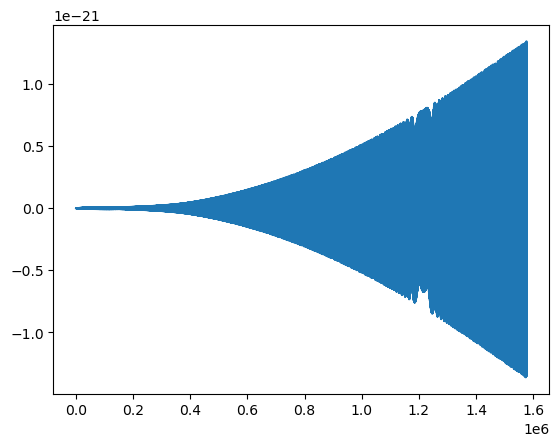

In [49]:
plt.plot((waveform_approx-waveform_true)[0].get())

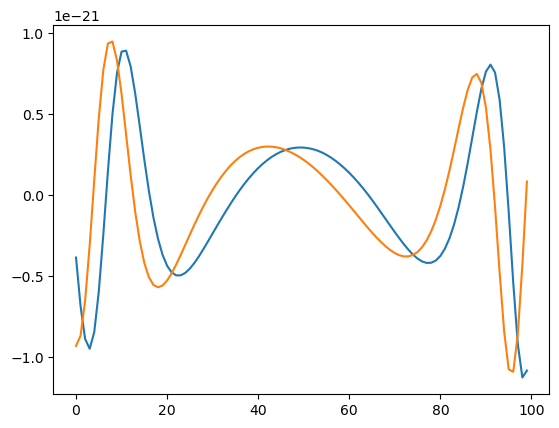

In [50]:
plt.plot((waveform_true)[0][-100:].get())
plt.plot((waveform_biased)[0][-100:].get())

In [51]:
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner=inner_product(waveform_biased,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_biased=np.sqrt(inner_product(waveform_biased,waveform_biased,PSD,dt,use_gpu=use_gpu))
diff_inner/((norm_true)*norm_biased)


np.float64(0.8686094518224833)

In [52]:
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
deviation_included=True
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0

deviation=biased_params-params_truth_in_considered

PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])

norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
delta = np.linspace(-1,1,500)
save_inner=[]
for i in range(len(delta)):
    biased = params_truth_in_considered + delta[i] * deviation
    dev_0_p= biased[9]
    dev_0_e= biased[10]
    add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
    add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,\
                    "deviation_included":deviation_included,"dev0p":dev_0_p,
        "dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

    pars_list = [np.exp(biased[0]), biased[1], biased[2], biased[3], \
             biased[4], xI0, dist, biased[5], biased[6], qK, phiK, biased[7], Phi_theta0,\
               biased[8]]
    waveform_considered = superkludge_wave(*pars_list, *add_args, dt=dt, T=T,use_gpu=use_gpu)
    diff_inner=inner_product(waveform_considered,waveform_true,PSD,dt,use_gpu=use_gpu)
    norm_biased=np.sqrt(inner_product(waveform_considered,waveform_considered,PSD,dt,use_gpu=use_gpu))
    mismatch=diff_inner/((norm_true)*norm_biased)
   #print(mismatch)
    save_inner.append(mismatch)


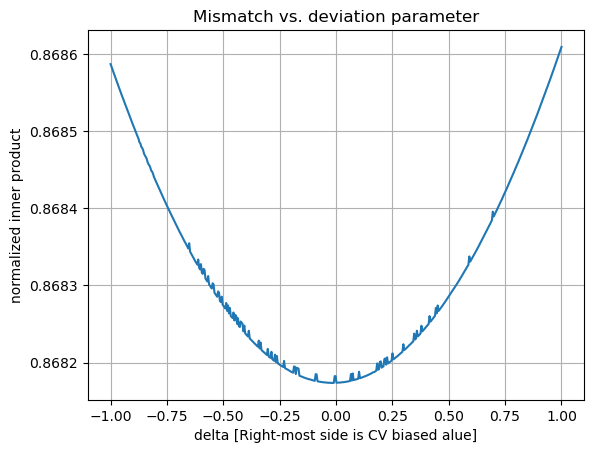

In [53]:
plt.plot(delta,save_inner)
plt.xlabel("delta [Right-most side is CV biased alue]")
plt.ylabel("normalized inner product")
plt.title("Mismatch vs. deviation parameter")
plt.grid(True)

In [54]:
print(np.max(save_inner))
delta[np.argmax(save_inner)]
#0.8587424254524265

0.8686094518224833


np.float64(1.0)

# ..
1. select mode to reduce noise